## Trial Results Summary

| context size | embedding dim | hidden layer size | kernel size | params | iterations | learning rate | train loss | val loss | note |
| -------- | -------- | -------- | -------- | -------- | -------- | -------- | -------- | -------- | -------- |
| 8 | 24 | 128 | 2 | 77k | 150k | 0.1 (iter<100k), 0.01 (iter>100k) | 1.7628 | 1.9881 | Andrej's params |
| 8 | 60 | 256 | 2 | 303k | 200k | 0.1 (iter<100k), 0.01 (iter>100k) | 1.4782 | 2.1981 | |
| 8 | 24 | 128 | 2 | 77k | 150k | 0.1 (iter<50k), 0.01 (50k<=iter<100k), 0.005 (100k<=iter) | 1.8329 | 1.9896 | my best attempt |
| 16 | 24 | 128 | 4 | 82k | 200k | 0.1 (iter<100k), 0.01 (iter>100k) | 1.8095 | 2.0034 | |


## makemore: part 5 (building a WaveNet)

[DeepMind blog post from 2016](https://www.deepmind.com/blog/wavenet-a-generative-model-for-raw-audio)

Goal: beat validation loss of 1.993

### Andrej's params
With validation loss in the plot

In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt  # for making figures
from tqdm import tqdm

%matplotlib inline
device = torch.device("cuda:1")
print(f"Using device: {device}")

Using device: cuda:1


In [2]:
words = open("../data/names.txt", "r").read().splitlines()
words[:10]

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

In [3]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set("".join(words))))
stoi = {s: i + 1 for i, s in enumerate(chars)}
stoi["."] = 0
itos = {i: s for s, i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [4]:
# shuffle up the words
import random

random.seed(42)
random.shuffle(words)

# build the dataset
block_size = 8  # context length: how many characters do we take to predict the next one?


def build_dataset(words):
    X, Y = [], []

    for w in words:
        context = [0] * block_size
        for ch in w + ".":
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]  # crop and append

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y


n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))
Xtr, Ytr = build_dataset(words[:n1])  # 80%
Xdev, Ydev = build_dataset(words[n1:n2])  # 10%
Xte, Yte = build_dataset(words[n2:])  # 10%

# gpu
Xtr, Ytr = Xtr.to(device), Ytr.to(device)
Xdev, Ydev = Xdev.to(device), Ydev.to(device)
Xte, Yte = Xte.to(device), Yte.to(device)

torch.Size([182625, 8]) torch.Size([182625])
torch.Size([22655, 8]) torch.Size([22655])
torch.Size([22866, 8]) torch.Size([22866])


In [5]:
# Near copy paste of the layers we have developed in Part 3

# -----------------------------------------------------------------------------------------------
class Linear:
    def __init__(self, fan_in, fan_out, bias=True):
        self.weight = torch.randn((fan_in, fan_out)) / fan_in**0.5  # note: kaiming init
        self.bias = torch.zeros(fan_out) if bias else None

    def __call__(self, x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out

    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])


# -----------------------------------------------------------------------------------------------
class BatchNorm1d:
    def __init__(self, dim, eps=1e-5, momentum=0.1, device=None):
        self.eps = eps
        self.momentum = momentum
        self.training = True
        # parameters (trained with backprop)
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)
        # buffers (trained with a running 'momentum update')
        self.running_mean = torch.zeros(dim, device=device)
        self.running_var = torch.ones(dim, device=device)

    def __call__(self, x):
        # calculate the forward pass
        if self.training:
            if x.ndim == 2:
                dim = 0
            elif x.ndim == 3:
                dim = (0, 1)
            xmean = x.mean(dim, keepdim=True)  # batch mean
            xvar = x.var(dim, keepdim=True)  # batch variance
        else:
            xmean = self.running_mean
            xvar = self.running_var
        xhat = (x - xmean) / torch.sqrt(xvar + self.eps)  # normalize to unit variance
        self.out = self.gamma * xhat + self.beta
        # update the buffers
        if self.training:
            with torch.no_grad():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
                self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
        return self.out

    def parameters(self):
        return [self.gamma, self.beta]


# -----------------------------------------------------------------------------------------------
class Tanh:
    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out

    def parameters(self):
        return []


# -----------------------------------------------------------------------------------------------
class Embedding:
    def __init__(self, num_embeddings, embedding_dim):
        self.weight = torch.randn((num_embeddings, embedding_dim))

    def __call__(self, IX):
        self.out = self.weight[IX]
        return self.out

    def parameters(self):
        return [self.weight]


# -----------------------------------------------------------------------------------------------
class FlattenConsecutive:
    def __init__(self, n):
        self.n = n

    def __call__(self, x):
        B, T, C = x.shape
        x = x.view(B, T // self.n, C * self.n)
        if x.shape[1] == 1:
            x = x.squeeze(1)
        self.out = x
        return self.out

    def parameters(self):
        return []


# -----------------------------------------------------------------------------------------------
class Sequential:
    def __init__(self, layers):
        self.layers = layers

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        self.out = x
        return self.out

    def parameters(self):
        # get parameters of all layers and stretch them out into one list
        return [p for layer in self.layers for p in layer.parameters()]

In [6]:
torch.manual_seed(42);  # seed rng for reproducibility

In [12]:
# original network
# n_embd = 10 # the dimensionality of the character embedding vectors
# n_hidden = 300 # the number of neurons in the hidden layer of the MLP
# model = Sequential([
#   Embedding(vocab_size, n_embd),
#   FlattenConsecutive(8), Linear(n_embd * 8, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
#   Linear(n_hidden, vocab_size),
# ])

# hierarchical network
n_embd = 24  # the dimensionality of the character embedding vectors
n_hidden = 128  # the number of neurons in the hidden layer of the MLP
model = Sequential(
    [
        Embedding(vocab_size, n_embd),
        FlattenConsecutive(2),
        Linear(n_embd * 2, n_hidden, bias=False),
        BatchNorm1d(n_hidden, device=device),
        Tanh(),
        FlattenConsecutive(2),
        Linear(n_hidden * 2, n_hidden, bias=False),
        BatchNorm1d(n_hidden, device=device),
        Tanh(),
        FlattenConsecutive(2),
        Linear(n_hidden * 2, n_hidden, bias=False),
        BatchNorm1d(n_hidden, device=device),
        Tanh(),
        Linear(n_hidden, vocab_size),
    ]
)

# parameter init
with torch.no_grad():
    model.layers[-1].weight *= 0.1  # last layer make less confident

parameters = model.parameters()
print(sum(p.nelement() for p in parameters))  # number of parameters in total
for p in parameters:
    p.requires_grad = True

# gpu
for p in parameters:
    p.data = p.data.to(device)

76579


In [7]:
def split_loss(split, batch_size=4096):
    x, y = {
        "train": (Xtr, Ytr),
        "val": (Xdev, Ydev),
        "test": (Xte, Yte),
    }[split]
    total, n = 0.0, 0
    for i in range(0, x.shape[0], batch_size):
        xb = x[i : i + batch_size].to(device)
        yb = y[i : i + batch_size].to(device)
        logits = model(xb)
        loss = F.cross_entropy(logits, yb)
        total += loss.item() * xb.shape[0]
        n += xb.shape[0]
    return total / n

In [8]:
def eval_mode(layers):
    for layer in layers:
        layer.training = False


def train_mode(layers):
    for layer in layers:
        layer.training = True

In [15]:
import math

# same optimization as last time
max_steps = 200000
batch_size = 32
losses_tr = []
losses_dev = []

for i in tqdm(range(max_steps)):
    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,))
    # Xb, Yb = Xtr[ix], Ytr[ix]  # batch X,Y
    Xb, Yb = Xtr[ix].to(device), Ytr[ix].to(device)  # gpu

    # forward pass
    logits = model(Xb)
    loss = F.cross_entropy(logits, Yb)  # loss function

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update: simple SGD
    lr = 0.1 if i < 150000 else 0.01  # step learning rate decay
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    losses_tr.append(loss.log10().item())
    if i % 1000 == 0:  # print every once in a while
        eval_mode(model.layers)

        loss_dev = split_loss("val")
        losses_dev.append(math.log10(loss_dev))

        train_mode(model.layers)

  0%|          | 0/200000 [00:00<?, ?it/s]

100%|██████████| 200000/200000 [13:52<00:00, 240.11it/s]


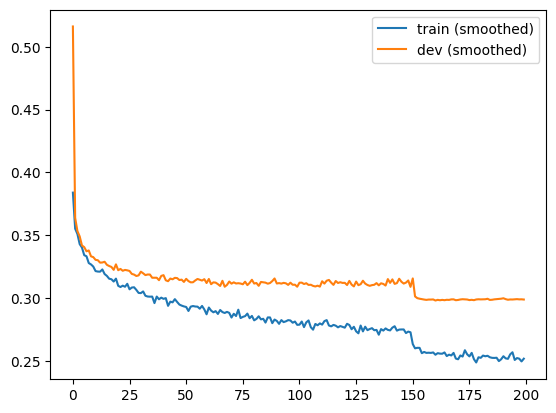

In [16]:
w = 1000
tr = [sum(losses_tr[i : i + w]) / w for i in range(0, len(losses_tr), w)]

plt.plot(tr, label="train (smoothed)")
plt.plot(losses_dev, label="dev (smoothed)")
plt.legend()
plt.show()

In [17]:
print(split_loss("train"))
print(split_loss("val"))

1.7628573213867094
1.9881206647051641


## experiment 1
| context size | embedding dim | hidden layer size | params | iterations | learning rate | train loss | val loss
| -------- | -------- | -------- | -------- | -------- | -------- | -------- | -------- |
| 8 | 60 | 256 | 303k | 200k | 0.1 (iter<100k), 0.01 (100k<iter)| 1.4782 | 2.1981 |

In [9]:
# hierarchical network
n_embd = 60  # the dimensionality of the character embedding vectors
n_hidden = 256  # the number of neurons in the hidden layer of the MLP
model = Sequential(
    [
        Embedding(vocab_size, n_embd),
        FlattenConsecutive(2),
        Linear(n_embd * 2, n_hidden, bias=False),
        BatchNorm1d(n_hidden, device=device),
        Tanh(),
        FlattenConsecutive(2),
        Linear(n_hidden * 2, n_hidden, bias=False),
        BatchNorm1d(n_hidden, device=device),
        Tanh(),
        FlattenConsecutive(2),
        Linear(n_hidden * 2, n_hidden, bias=False),
        BatchNorm1d(n_hidden, device=device),
        Tanh(),
        Linear(n_hidden, vocab_size),
    ]
)

# parameter init
with torch.no_grad():
    model.layers[-1].weight *= 0.1  # last layer make less confident

parameters = model.parameters()
print(sum(p.nelement() for p in parameters))  # number of parameters in total
for p in parameters:
    p.requires_grad = True

# gpu
for p in parameters:
    p.data = p.data.to(device)

302959


In [10]:
import math

# same optimization as last time
max_steps = 200000
batch_size = 128
losses_tr = []
losses_dev = []

for i in tqdm(range(max_steps)):
    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,))
    # Xb, Yb = Xtr[ix], Ytr[ix]  # batch X,Y
    Xb, Yb = Xtr[ix].to(device), Ytr[ix].to(device)  # gpu

    # forward pass
    logits = model(Xb)
    loss = F.cross_entropy(logits, Yb)  # loss function

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update: simple SGD
    lr = 0.1 if i < 100000 else 0.01  # step learning rate decay
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    losses_tr.append(loss.log10().item())
    if i % 1000 == 0:  # print every once in a while
        eval_mode(model.layers)

        loss_dev = split_loss("val")
        losses_dev.append(math.log10(loss_dev))

        train_mode(model.layers)


100%|██████████| 200000/200000 [11:29<00:00, 289.87it/s]


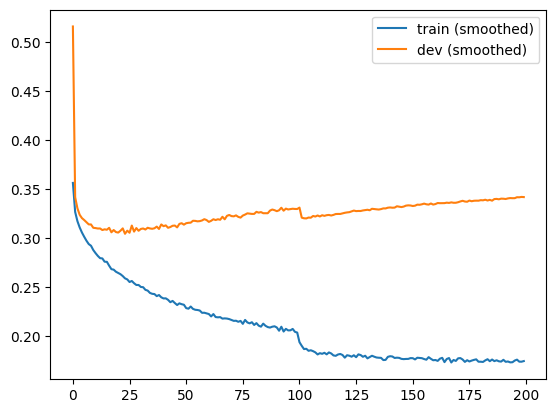

In [11]:
w = 1000
tr = [sum(losses_tr[i : i + w]) / w for i in range(0, len(losses_tr), w)]

plt.plot(tr, label="train (smoothed)")
plt.plot(losses_dev, label="dev (smoothed)")
plt.legend()
plt.show()

In [12]:
print("train loss", split_loss("train"))
print("val loss", split_loss("val"))

train loss 1.4782747774228586
val loss 2.1981492911603797


## experiment 2
| context size | embedding dim | hidden layer size | params | iterations | learning rate | train loss | val loss
| -------- | -------- | -------- | -------- | -------- | -------- | -------- | -------- |
| 8 | 24 | 128 | 77k | 150k | 0.1 (iter<50k), 0.01 (50k<=iter<100k), 0.005 (100k<=iter)| 1.8329 | 1.9896 |

In [9]:
# hierarchical network
n_embd = 24  # the dimensionality of the character embedding vectors
n_hidden = 128  # the number of neurons in the hidden layer of the MLP
model = Sequential(
    [
        Embedding(vocab_size, n_embd),
        FlattenConsecutive(2),
        Linear(n_embd * 2, n_hidden, bias=False),
        BatchNorm1d(n_hidden, device=device),
        Tanh(),
        FlattenConsecutive(2),
        Linear(n_hidden * 2, n_hidden, bias=False),
        BatchNorm1d(n_hidden, device=device),
        Tanh(),
        FlattenConsecutive(2),
        Linear(n_hidden * 2, n_hidden, bias=False),
        BatchNorm1d(n_hidden, device=device),
        Tanh(),
        Linear(n_hidden, vocab_size),
    ]
)

# parameter init
with torch.no_grad():
    model.layers[-1].weight *= 0.1  # last layer make less confident

parameters = model.parameters()
print(sum(p.nelement() for p in parameters))  # number of parameters in total
for p in parameters:
    p.requires_grad = True

# gpu
for p in parameters:
    p.data = p.data.to(device)

76579


In [10]:
import math

# same optimization as last time
max_steps = 150000
batch_size = 32
losses_tr = []
losses_dev = []

for i in tqdm(range(max_steps)):
    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,))
    # Xb, Yb = Xtr[ix], Ytr[ix]  # batch X,Y
    Xb, Yb = Xtr[ix].to(device), Ytr[ix].to(device)  # gpu

    # forward pass
    logits = model(Xb)
    loss = F.cross_entropy(logits, Yb)  # loss function

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # learning rate scheduler
    if i < 50000:
        lr = 0.1
    elif i < 100000:
        lr = 0.01
    else:
        lr = 0.005

    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    losses_tr.append(loss.log10().item())
    if i % 1000 == 0:  # print every once in a while
        eval_mode(model.layers)

        loss_dev = split_loss("val")
        losses_dev.append(math.log10(loss_dev))

        train_mode(model.layers)

100%|██████████| 150000/150000 [08:42<00:00, 286.92it/s]


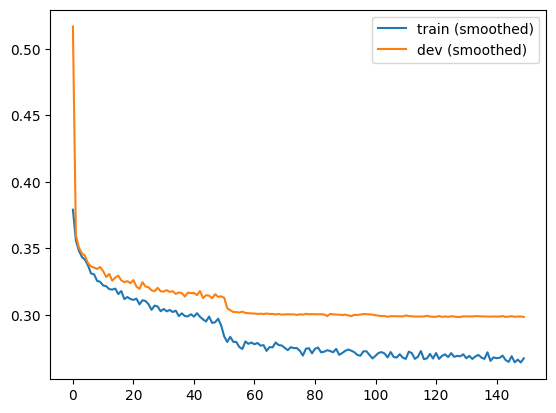

In [11]:
w = 1000
tr = [sum(losses_tr[i : i + w]) / w for i in range(0, len(losses_tr), w)]

plt.plot(tr, label="train (smoothed)")
plt.plot(losses_dev, label="dev (smoothed)")
plt.legend()
plt.show()

In [12]:
print("train loss", split_loss("train"))
print("val loss", split_loss("val"))

train loss 1.8328848842572545
val loss 1.98956358105477


## trial 3
| context size | embedding dim | hidden layer size | kernel size | params | iterations | learning rate | train loss | val loss
| -------- | -------- | -------- | -------- | -------- | -------- | -------- | -------- | -------- |
| 16 | 24 | 128 | 4 | 82k | 200k | 0.1 (iter<100k), 0.01 (100k<=iter) | 1.8095 | 2.0034 |

In [13]:
# shuffle up the words
import random

random.seed(42)
random.shuffle(words)

# build the dataset
block_size = 16  # context length: how many characters do we take to predict the next one?


def build_dataset(words):
    X, Y = [], []

    for w in words:
        context = [0] * block_size
        for ch in w + ".":
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]  # crop and append

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y


n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))
Xtr, Ytr = build_dataset(words[:n1])  # 80%
Xdev, Ydev = build_dataset(words[n1:n2])  # 10%
Xte, Yte = build_dataset(words[n2:])  # 10%

# gpu
Xtr, Ytr = Xtr.to(device), Ytr.to(device)
Xdev, Ydev = Xdev.to(device), Ydev.to(device)
Xte, Yte = Xte.to(device), Yte.to(device)

torch.Size([182580, 16]) torch.Size([182580])
torch.Size([22767, 16]) torch.Size([22767])
torch.Size([22799, 16]) torch.Size([22799])


In [14]:
# hierarchical network
n_embd = 24  # the dimensionality of the character embedding vectors
n_hidden = 128  # the number of neurons in the hidden layer of the MLP
model = Sequential(
    [
        Embedding(vocab_size, n_embd),
        FlattenConsecutive(4),
        Linear(n_embd * 4, n_hidden, bias=False),
        BatchNorm1d(n_hidden, device=device),
        Tanh(),
        FlattenConsecutive(4),
        Linear(n_hidden * 4, n_hidden, bias=False),
        BatchNorm1d(n_hidden, device=device),
        Tanh(),
        Linear(n_hidden, vocab_size),
    ]
)

# parameter init
with torch.no_grad():
    model.layers[-1].weight *= 0.1  # last layer make less confident

parameters = model.parameters()
print(sum(p.nelement() for p in parameters))  # number of parameters in total
for p in parameters:
    p.requires_grad = True

# gpu
for p in parameters:
    p.data = p.data.to(device)

82467


In [15]:
import math

# same optimization as last time
max_steps = 200000
batch_size = 32
losses_tr = []
losses_dev = []

for i in tqdm(range(max_steps)):
    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,))
    # Xb, Yb = Xtr[ix], Ytr[ix]  # batch X,Y
    Xb, Yb = Xtr[ix].to(device), Ytr[ix].to(device)  # gpu

    # forward pass
    logits = model(Xb)
    loss = F.cross_entropy(logits, Yb)  # loss function

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    losses_tr.append(loss.log10().item())
    if i % 1000 == 0:  # print every once in a while
        eval_mode(model.layers)

        loss_dev = split_loss("val")
        losses_dev.append(math.log10(loss_dev))

        train_mode(model.layers)

100%|██████████| 200000/200000 [08:51<00:00, 376.55it/s]


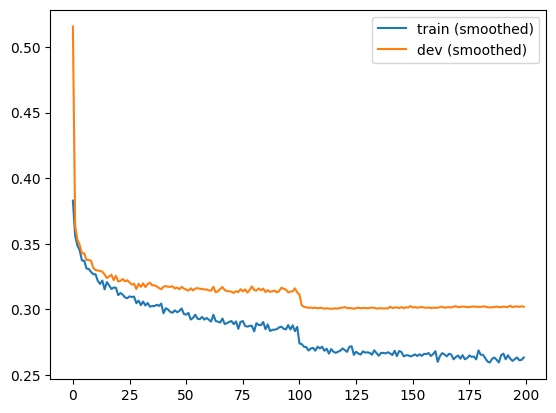

In [16]:
w = 1000
tr = [sum(losses_tr[i : i + w]) / w for i in range(0, len(losses_tr), w)]

plt.plot(tr, label="train (smoothed)")
plt.plot(losses_dev, label="dev (smoothed)")
plt.legend()
plt.show()

In [17]:
print("train loss", split_loss("train"))
print("val loss", split_loss("val"))

train loss 1.809541989265991
val loss 2.0034413049829154
